In [20]:
import operator
from typing import Annotated, List, TypedDict, Dict, Any, Literal
# from langchain_community.chat_models import GigaChat
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import GigaChatEmbeddings
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command

In [21]:
class AgentState(TypedDict):
    # messages accumulates conversation history via the 'add' reducer
    messages: Annotated[List[BaseMessage], operator.add]
    deal_id: str
    context_snippets: List[str]
    detected_bottlenecks: List[str]
    suggested_tasks: List[str]
    is_validated: bool


In [ ]:


# 2. Node Implementations
class DealFlowAgents:
    def __init__(self, deal_id: str):
        self.deal_id = deal_id
        # Using Sber's Giga-Embeddings for the Vector DB
        # self.embeddings = GigaChatEmbeddings(credentials="YOUR_AUTH", verify_ssl_certs=False)
        # self.vector_db = Chroma(persist_directory="./deal_memory", embedding_function=self.embeddings)
        # self.llm = GigaChat(credentials="YOUR_AUTH", model="GigaChat-Pro", verify_ssl_certs=False)

    def scribe_node(self, state: AgentState):
        """Stores new communications into the Vector DB and updates context."""
        new_msg = state["messages"][-1].content
        self.vector_db.add_texts([new_msg], metadatas=[{"deal_id": self.deal_id}])
        
        # Retrieve recent context from Vector DB for the current reasoning step
        docs = self.vector_db.similarity_search(new_msg, k=3, filter={"deal_id": self.deal_id})
        snippets = [doc.page_content for doc in docs]
        
        return {"context_snippets": snippets}

    def analyst_node(self, state: AgentState):
        """Analyzes context to find bottlenecks (e.g., SRVA delays, licensing issues)."""
        context = "\n".join(state["context_snippets"])
        prompt = f"Based on this trade context: {context}\nIdentify any blocking factors for the deal."
        
        # Simulate LLM identifying a bottleneck
        response = self.llm.invoke(prompt)
        return {"detected_bottlenecks": [response.content]}

    def strategist_node(self, state: AgentState):
        """Generates actionable tasks for the Sber Specialist."""
        bottlenecks = ", ".join(state["detected_bottlenecks"])
        prompt = f"Bottleneck detected: {bottlenecks}. Suggest a specific task for a Sber BD Manager."
        
        response = self.llm.invoke(prompt)
        return {"suggested_tasks": [response.content]}

    def gatekeeper_node(self, state: AgentState):
        """Pauses the graph to allow the human (Sber Specialist) to review/edit the task."""
        # The 'interrupt' function pauses execution and waits for a 'resume' Command
        print("\n--- ⏸️ GATEKEEPER: Awaiting Sber Specialist Approval ---")
        
        review_payload = {
            "task_to_approve": state["suggested_tasks"][-1],
            "bottleneck_found": state["detected_bottlenecks"][-1]
        }
        
        # Execution halts here until graph.stream(Command(resume=...)) is called
        human_input = interrupt(review_payload)
        
        if human_input.get("action") == "approve":
            return {"is_validated": True, "suggested_tasks": [human_input.get("edited_task", state["suggested_tasks"][-1])]}
        else:
            # If rejected, we route back to Strategist (handled in Graph logic)
            return {"is_validated": False}

    def executor_node(self, state: AgentState):
        """Final node that logs the task to the internal CRM/Project System."""
        final_task = state["suggested_tasks"][-1]
        print(f"--- ✅ EXECUTOR: Task officially logged: {final_task} ---")
        return state

# 3. Graph Construction
def build_dealflow_graph(deal_id: str):
    agents = DealFlowAgents(deal_id)
    workflow = StateGraph(AgentState)

    workflow.add_node("scribe", agents.scribe_node)
    workflow.add_node("analyst", agents.analyst_node)
    workflow.add_node("strategist", agents.strategist_node)
    workflow.add_node("gatekeeper", agents.gatekeeper_node)
    workflow.add_node("executor", agents.executor_node)

    workflow.add_edge(START, "scribe")
    workflow.add_edge("scribe", "analyst")
    workflow.add_edge("analyst", "strategist")
    workflow.add_edge("strategist", "gatekeeper")

    # Routing logic based on human input in the gatekeeper
    def route_after_gatekeeper(state: AgentState):
        if state["is_validated"]:
            return "executor"
        return "strategist" # Retry strategy if human rejects

    workflow.add_conditional_edges("gatekeeper", route_after_gatekeeper)
    workflow.add_edge("executor", END)

    # Persistence is required for 'interrupt' to work
    checkpointer = InMemorySaver()
    return workflow.compile(checkpointer=checkpointer)

# 4. Example Execution Loop
if __name__ == "__main__":
    deal_graph = build_dealflow_graph("DEAL-789-PHARMA")
    config = {"configurable": {"thread_id": "session_1"}}

    # Initial Input from India-Russia comms
    email_input = {"messages":"qaasadf"}

    # First Run: Will stop at the gatekeeper
    print("\n--- Starting Deal Analysis ---")
    for event in deal_graph.stream(email_input, config):
        if "__interrupt__" in event:
            print("Current Recommendation:", event["__interrupt__"].value)

    # Simulation of Human Intervention (Sber Specialist provides feedback)
    print("\n--- Specialist is reviewing the task... ---")
    # Specialist edits the task to be more specific
    human_command = Command(resume={
        "action": "approve", 
        "edited_task": "Urgent: Coordinate with Mumbai Treasury to clear the Sun Pharma SRVA bottleneck within 24 hours."
    })

    # Second Run: Resumes from the gatekeeper
    for event in deal_graph.stream(human_command, config):
        print(event)

In [11]:
agents = DealFlowAgents("DEAL-789-PHARMA")
workflow = StateGraph(AgentState)

workflow.add_node("scribe", agents.scribe_node)
workflow.add_node("analyst", agents.analyst_node)
workflow.add_node("strategist", agents.strategist_node)
workflow.add_node("gatekeeper", agents.gatekeeper_node)
workflow.add_node("executor", agents.executor_node)

workflow.add_edge(START, "scribe")
workflow.add_edge("scribe", "analyst")
workflow.add_edge("analyst", "strategist")
workflow.add_edge("strategist", "gatekeeper")
workflow.add_conditional_edges("gatekeeper", route_after_gatekeeper)
workflow.add_edge("executor", END)

In [10]:
def route_after_gatekeeper(state: AgentState):
        if state["is_validated"]:
            return "executor"
        return "strategist" # Retry strategy if human rejects


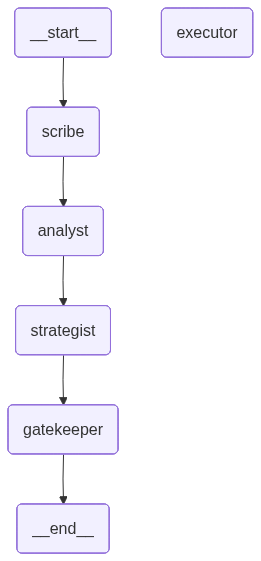

In [19]:
checkpointer = InMemorySaver()
workflow.compile(checkpointer=checkpointer)

In [ ]:
from IPython.display import Image, display

# Requires no extra libraries besides ipython
display(Image(data=workflow.get_graph().draw_mermaid_png()))


AttributeError: 'DealFlowAgents' object has no attribute 'get_graph'